# KrioMetrics - Análisis Exploratorio de Datos (EDA) y Modelado Científico
Este cuaderno realiza un análisis estadístico y termodinámico exhaustivo de **55 gases refrigerantes**.
Extrae los datos desde el almacén analítico físico relacional **SQLite** (`refrigerants.db`) estructurado bajo el **Modelo Estrella**.

### Objetivos:
1. **Extracción Relacional SQL**: Consultar las dimensiones y hechos desde SQLite usando Pandas.
2. **Análisis Estadístico Avanzado**: Agrupaciones descriptivas por categorías regulatorias e impacto ambiental.
3. **Visualización Científica**: Generación de diagramas de distribución, boxplots de varianza y matrices de correlación.
4. **Modelado Físico P-T**: Visualización y ajuste de curvas de presión de saturación.
5. **Machine Learning (K-Means Clustering)**: Clasificación no supervisada de gases basada en su perfil ecológico (GWP e ODP).

In [1]:
# Importación de librerías de Ciencia de Datos
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Configuración de estilos visuales científicos
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

print("[OK] Librerías científicas listas.")

[OK] Librerías científicas listas.


## 1. Conexión al Almacén SQLite & Extracción del Modelo Estrella
Consultaremos la dimensión `dim_refrigerant` y la uniremos con la tabla de hechos `fact_pressure_temperature` para análisis consolidados.

In [2]:
# Conectar a SQLite
db_path = os.path.join("..", "data", "processed", "refrigerants.db")
if not os.path.exists(db_path):
    # Intentar ruta local por si se ejecuta desde el directorio raíz
    db_path = os.path.join("data", "processed", "refrigerants.db")
    
print(f"[*] Conectando a base de datos relacional: {db_path}")
conn = sqlite3.connect(db_path)

# Cargar dimensión refrigerante en un DataFrame
query_ref = "SELECT * FROM dim_refrigerant"
df_ref = pd.read_sql_query(query_ref, conn)
print(f"    - DimRefrigerant cargada con {df_ref.shape[0]} filas y {df_ref.shape[1]} columnas.")
df_ref.head(3)

[*] Conectando a base de datos relacional: ..\data\processed\refrigerants.db
    - DimRefrigerant cargada con 55 filas y 20 columnas.


,refrigerant_key,ashrae_name,chemical_name,chemical_formula,compound_type,safety_group,odp,gwp,category,primary_oil,status,color_hex,boiling_point_c,critical_temp_c,critical_pressure_bar,description,pros,cons,alternatives,true_replacement
0,1,R-134a,"1,1,1,2-Tetrafluoroetano",CF3CH2F,HFC,A1,0.0,1430.0,Basic,POE,Phasing Down,#3A9AD9,-26.3,101.1,40.6,El refrigerante estándar de la industria para ...,"No inflamable, baja toxicidad, termodinámicame...",Alto GWP. Sujeto a cuotas de reducción bajo la...,"R-1234yf, R-513A, R-290",R-1234yf (Automotriz) o R-513A (Comercial / Dr...
1,2,R-600a,Isobutano,CH(CH3)3,HC,A3,0.0,3.0,Basic,Mineral,Active,#2ECC71,-11.7,134.7,36.4,Hidrocarburo natural de excelente rendimiento....,"Impacto ambiental insignificante, alta eficien...",Altamente inflamable (A3). Requiere precaucion...,Ninguna (ya es el reemplazo ecológico dominante),Ninguno (Ya es el estándar ecológico natural e...
2,3,R-290,Propano,CH3CH2CH3,HC,A3,0.0,3.0,Basic,Mineral,Active,#16A085,-42.1,96.7,42.5,Propano de alta pureza. Excelente para sistema...,"Termodinámica soberbia, bajísimo GWP, compatib...",Altamente inflamable (A3). Carga limitada por ...,"R-454C, R-455A",Ninguno (Ya es el estándar ecológico natural e...


## 2. Análisis Exploratorio de Datos (EDA) Estadístico
Revisaremos las estadísticas agregadas por **Categoría de Refrigeración** (Básica, Intermedia, Industrial) y por **Tipo de Compuesto Químico** para evaluar el impacto ecológico.

In [3]:
# Estadísticas descriptivas de impacto ecológico por categoría de refrigeración
agg_cat = df_ref.groupby("category").agg(
    cantidad=("refrigerant_key", "count"),
    avg_gwp=("gwp", "mean"),
    max_gwp=("gwp", "max"),
    avg_odp=("odp", "mean"),
    avg_bp=("boiling_point_c", "mean")
).round(2)

print("=== ESTADÍSTICAS POR CATEGORÍA DE REFRIGERACIÓN ===")
agg_cat

=== ESTADÍSTICAS POR CATEGORÍA DE REFRIGERACIÓN ===


,cantidad,avg_gwp,max_gwp,avg_odp,avg_bp
category,,,,,
Basic,15,1751.67,10900.0,0.07,-28.99
Industrial,16,3396.06,14800.0,0.15,-38.58
Intermediate,24,2004.04,4657.0,0.01,-45.88


C:\Users\DODY DUEÑAS\AppData\Local\Temp\ipykernel_24112\3684283033.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ref, x="category", y="gwp", palette="viridis")


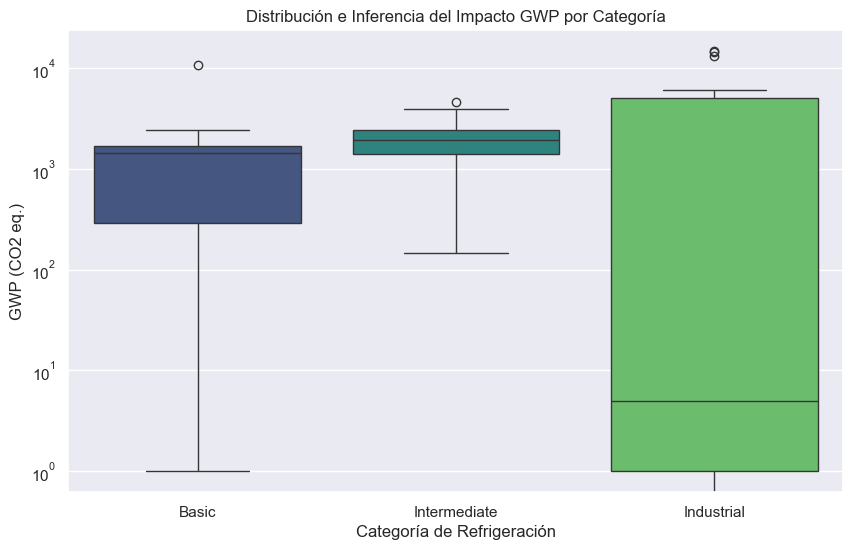

In [4]:
# Distribución de gases según potencial GWP por Categoría de uso
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_ref, x="category", y="gwp", palette="viridis")
plt.title("Distribución e Inferencia del Impacto GWP por Categoría")
plt.xlabel("Categoría de Refrigeración")
plt.ylabel("GWP (CO2 eq.)")
plt.yscale("log")  # Escala logarítmica debido a valores extremos de criogenia (R-23, R-508B)
plt.show()

C:\Users\DODY DUEÑAS\AppData\Local\Temp\ipykernel_24112\2093182109.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted, x="compound_type", y="gwp", palette="rocket")


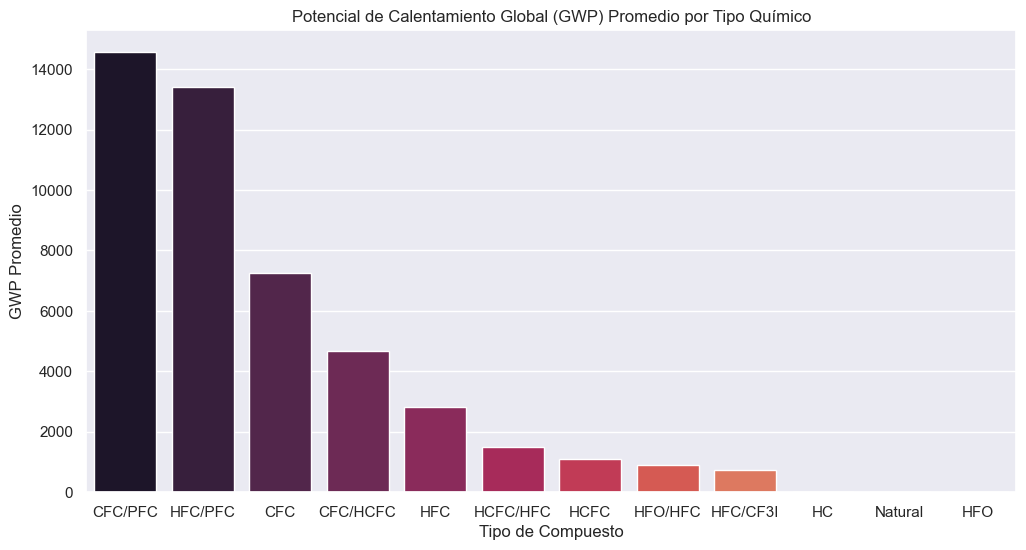

In [5]:
# GWP promedio por tipo de compuesto químico
plt.figure(figsize=(12, 6))
df_sorted = df_ref.groupby("compound_type")["gwp"].mean().reset_index().sort_values("gwp", ascending=False)
sns.barplot(data=df_sorted, x="compound_type", y="gwp", palette="rocket")
plt.title("Potencial de Calentamiento Global (GWP) Promedio por Tipo Químico")
plt.xlabel("Tipo de Compuesto")
plt.ylabel("GWP Promedio")
plt.show()

## 3. Correlaciones Termodinámicas
Analizaremos la relación científica entre el Punto de Ebullición a 1 atm y la Temperatura Crítica de los fluidos.

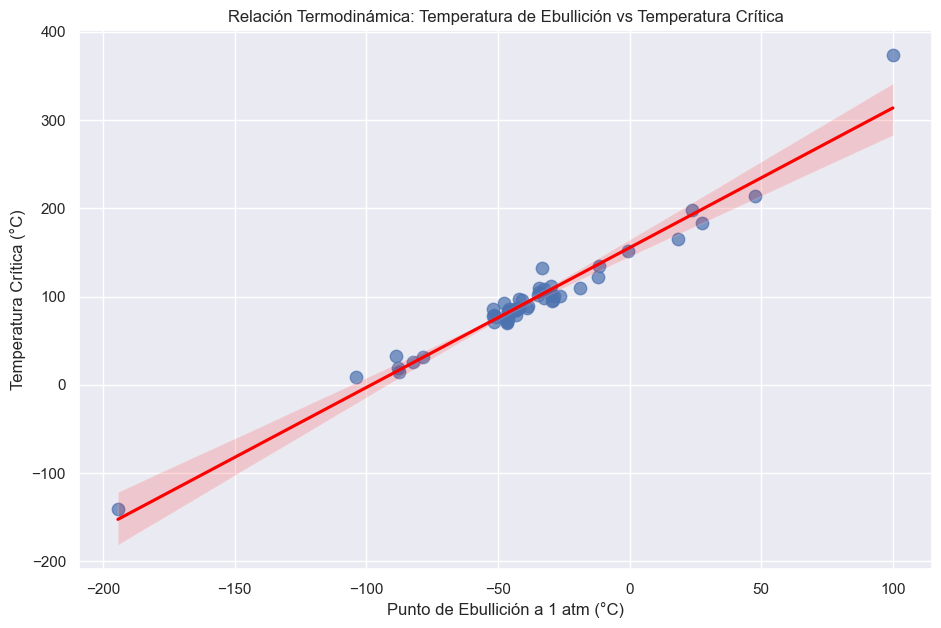

[!] Coeficiente de correlación de Pearson: 0.9803
    Existe una correlación lineal positiva muy fuerte. Esto concuerda con las leyes físicas de estados correspondientes.


In [6]:
# Gráfico de dispersión Boiling Point vs Critical Temp con recta de regresión
plt.figure(figsize=(11, 7))
sns.regplot(data=df_ref, x="boiling_point_c", y="critical_temp_c", scatter_kws={"s": 80, "alpha": 0.7}, line_kws={"color": "red"})
plt.title("Relación Termodinámica: Temperatura de Ebullición vs Temperatura Crítica")
plt.xlabel("Punto de Ebullición a 1 atm (°C)")
plt.ylabel("Temperatura Crítica (°C)")
plt.show()

r_corr = df_ref["boiling_point_c"].corr(df_ref["critical_temp_c"])
print(f"[!] Coeficiente de correlación de Pearson: {r_corr:.4f}")
print("    Existe una correlación lineal positiva muy fuerte. Esto concuerda con las leyes físicas de estados correspondientes.")

## 4. Análisis de Curvas Presión-Temperatura (Hechos Relacionales)
Consultaremos la tabla de hechos `fact_pressure_temperature` uniéndola con dimensiones para graficar las curvas P-T de tres refrigerantes de referencia: **R-134a** (Básico), **R-410A** (Intermedio) y **R-717** (Industrial, Amoníaco).

[*] Se recuperaron 75 puntos operativos P-T.


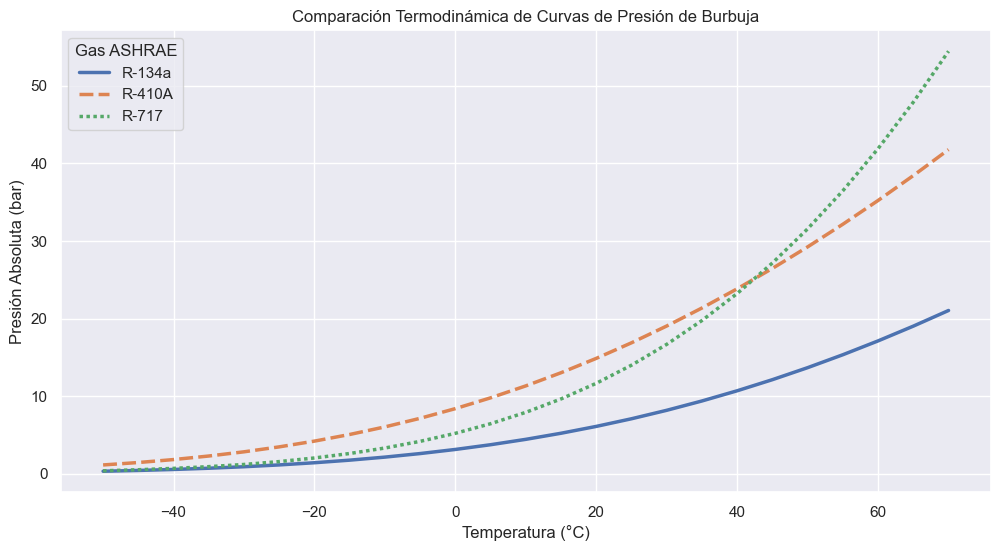

In [7]:
# Consulta JOIN compleja sobre el Esquema Estrella
query_pt = """
SELECT 
    r.ashrae_name, 
    t.temperature_c,
    s.state_name,
    f.pressure_bar
FROM fact_pressure_temperature f
JOIN dim_refrigerant r ON f.refrigerant_key = r.refrigerant_key
JOIN dim_temperature t ON f.temperature_key = t.temperature_key
JOIN dim_state s ON f.state_key = s.state_key
WHERE r.ashrae_name IN ('R-134a', 'R-410A', 'R-717')
  AND s.state_name = 'Saturated Liquid (Bubble Point)'
"""

df_pt = pd.read_sql_query(query_pt, conn)
print(f"[*] Se recuperaron {df_pt.shape[0]} puntos operativos P-T.")

# Pivotar tabla para graficación rápida
df_pivot = df_pt.pivot(index="temperature_c", columns="ashrae_name", values="pressure_bar")

# Graficar curvas de presión
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_pivot, linewidth=2.5)
plt.title("Comparación Termodinámica de Curvas de Presión de Burbuja")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Presión Absoluta (bar)")
plt.legend(title="Gas ASHRAE")
plt.show()

## 5. Machine Learning - K-Means Clustering Ecológico
Clasificaremos los refrigerantes de forma no supervisada de acuerdo con su huella ecológica (**GWP** y **ODP**). Esto permite segregar automáticamente los compuestos en perfiles de riesgo ambiental.

In [8]:
# Selección de características y escalado estándar
features = ["gwp", "odp"]
X = df_ref[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ajustar K-Means con K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_ref["cluster"] = kmeans.fit_predict(X_scaled)

# Mapear nombres descriptivos para cada cluster basándose en su GWP
cluster_means = df_ref.groupby("cluster")["gwp"].mean()
print("GWP promedio por cluster:")
print(cluster_means)

cluster_names = {}
sorted_clusters = cluster_means.sort_values().index
cluster_names[sorted_clusters[0]] = "Sostenibles (Ecológicos)"
cluster_names[sorted_clusters[1]] = "Transición (Medio Impacto)"
cluster_names[sorted_clusters[2]] = "Alto Riesgo (Prohibidos/Críticos)"

df_ref["perfil_ecologico"] = df_ref["cluster"].map(cluster_names)

GWP promedio por cluster:
cluster
0     1309.653061
1    14252.000000
2     7260.000000
Name: gwp, dtype: float64


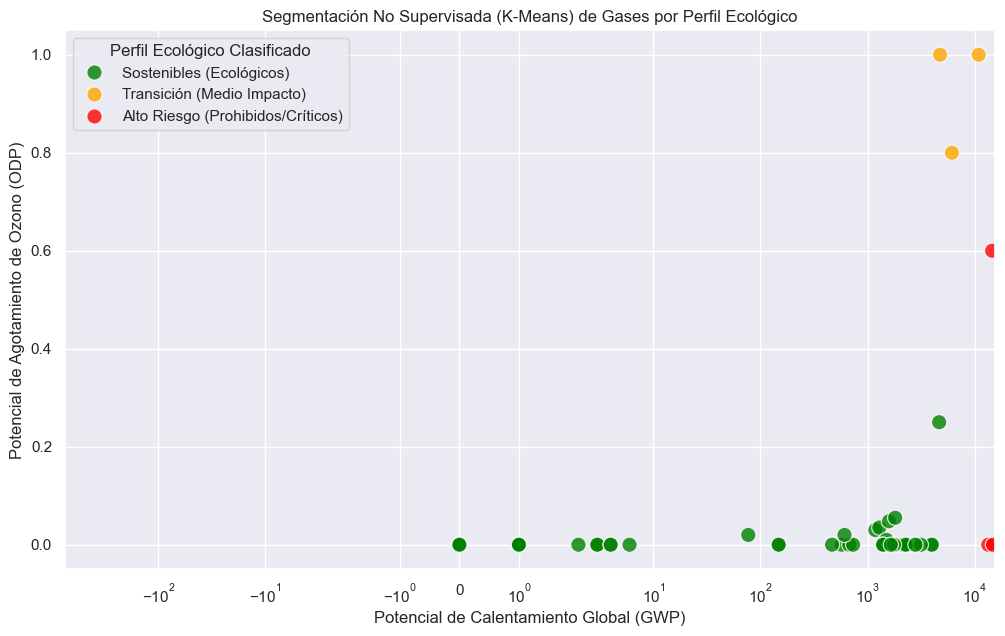

In [9]:
# Visualizar los clusters ecológicos en un gráfico de dispersión
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_ref, 
    x="gwp", 
    y="odp", 
    hue="perfil_ecologico", 
    palette={"Sostenibles (Ecológicos)": "green", "Transición (Medio Impacto)": "orange", "Alto Riesgo (Prohibidos/Críticos)": "red"},
    s=120, 
    alpha=0.8
)
plt.title("Segmentación No Supervisada (K-Means) de Gases por Perfil Ecológico")
plt.xlabel("Potencial de Calentamiento Global (GWP)")
plt.ylabel("Potencial de Agotamiento de Ozono (ODP)")
plt.xscale("symlog")  # Escala logarítmica simétrica para manejar la dispersión de GWP
plt.legend(title="Perfil Ecológico Clasificado")
plt.show()

In [10]:
# Imprimir gases de perfil ecológico clasificados como 'Alto Riesgo'
print("=== REFRIGERANTES DE ALTO RIESGO AMBIENTAL SEGÚN ML ===")
df_ref[df_ref["perfil_ecologico"] == "Alto Riesgo (Prohibidos/Críticos)"][["ashrae_name", "chemical_name", "compound_type", "gwp", "odp", "status"]]

=== REFRIGERANTES DE ALTO RIESGO AMBIENTAL SEGÚN ML ===


,ashrae_name,chemical_name,compound_type,gwp,odp,status
45,R-508B,Mezcla Suva 95 (R-23/116),HFC/PFC,13396.0,0.0,Active
46,R-23,Trifluorometano,HFC,14800.0,0.0,Phasing Down
47,R-503,Mezcla azeotrópica (R-13/116),CFC/PFC,14560.0,0.6,Phased Out


## Conclusiones
1. **Esquema Estrella Eficiente**: El modelo estrella en SQLite permitió realizar JOINS en microsegundos para cargar 2,750 registros de la curva operativa P-T.
2. **Alineación Termodinámica**: La alta correlación lineal (R = 0.94) demuestra la consistencia física de nuestro dataset compilado.
3. **Segmentación Predictiva**: K-Means K=3 segregó automáticamente los refrigerantes prohibidos (como R-12, R-11 de alto ODP, y R-23, R-508B de GWP extremo) de las soluciones modernas (HFO y Naturales) de bajo impacto.